In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [45]:
# Cell 2: Simplified Ocular AI Model Class
class SimpleOcularAIModel:
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.history = None
        self.feature_columns = None
        
    def prepare_data(self, df):
        """
        Prepare data for training
        """
        # Separate identifiers, features, and targets
        identifiers = ['pront', 'sexo', 'olho_operado','cilindrico_pos', 'eixo_pos']
        target_columns = ['esferico_pos']
        
        # All other columns are features
        self.feature_columns = [col for col in df.columns 
                               if col not in identifiers + target_columns]
        
        X = df[self.feature_columns]
        y = df[target_columns]
        
        # Handle any remaining missing values
        X = X.fillna(X.mean())
        y = y.fillna(y.mean())
        
        return X, y
    
    def create_simple_model(self, input_dim, learning_rate=0.001):
        """
        Create a simple, regularized neural network for small datasets
        """
        model = keras.Sequential([
            layers.Dense(32, activation='relu', input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            
            layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.1),
            
            layers.Dense(1, activation='linear')  # apenas 1 saída agora
        ])
        
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        return model
    
    def train_simple(self, df, test_size=0.2, validation_split=0.25, epochs=100, batch_size=4):
        """
        Train the simplified neural network model
        """
        # Prepare data
        X, y = self.prepare_data(df)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Create simple model
        self.model = self.create_simple_model(X_train_scaled.shape[1])
        
        print("Simplified Model Architecture:")
        self.model.summary()
        
        # Simple callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(
                patience=15,
                restore_best_weights=True,
                monitor='val_loss'
            ),
            keras.callbacks.ReduceLROnPlateau(
                factor=0.5,
                patience=8,
                min_lr=1e-7
            )
        ]
        
        print(f"\nTraining simplified model for {epochs} epochs...")
        # Train model
        self.history = self.model.fit(
            X_train_scaled, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate model
        train_metrics = self.model.evaluate(X_train_scaled, y_train, verbose=0)
        test_metrics = self.model.evaluate(X_test_scaled, y_test, verbose=0)
        
        print(f"\nTraining Metrics - Loss: {train_metrics[0]:.4f}, MAE: {train_metrics[1]:.4f}")
        print(f"Test Metrics - Loss: {test_metrics[0]:.4f}, MAE: {test_metrics[1]:.4f}")
        
        return X_test_scaled, y_test, X_train_scaled, y_train
    
    def cross_validate(self, df, n_splits=5, epochs=80, batch_size=8):
        """
        Perform k-fold cross-validation on the entire dataset
        """
        print(f"Starting {n_splits}-fold Cross-Validation...")
        print(f"Dataset size: {len(df)} samples")
        
        # Prepare data
        X, y = self.prepare_data(df)
        X_scaled = self.scaler.fit_transform(X)
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        # Store results
        fold_results = []
        all_predictions = []
        all_actuals = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
            print(f"\n{'='*50}")
            print(f"Fold {fold + 1}/{n_splits}")
            print(f"Training samples: {len(train_idx)}, Validation samples: {len(val_idx)}")
            print(f"{'='*50}")
            
            # Split data for this fold
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Create and train model for this fold
            model = self.create_simple_model(X_train.shape[1])
            
            # Train with early stopping
            history = model.fit(
                X_train, y_train,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                verbose=0,
                callbacks=[
                    keras.callbacks.EarlyStopping(
                        patience=12, 
                        restore_best_weights=True,
                        monitor='val_loss'
                    )
                ]
            )
            
            # Evaluate on validation set
            val_predictions = model.predict(X_val, verbose=0)
            
            # Calculate metrics for each target
            fold_metrics = {}
            target_names = ['esferico_pos']
            
            for i, name in enumerate(target_names):
                mse = mean_squared_error(y_val.iloc[:, i], val_predictions[:, i])
                mae = mean_absolute_error(y_val.iloc[:, i], val_predictions[:, i])
                r2 = r2_score(y_val.iloc[:, i], val_predictions[:, i])
                
                fold_metrics[name] = {
                    'mse': mse,
                    'mae': mae,
                    'r2': r2
                }
            
            # Store overall fold results
            fold_loss, fold_mae = model.evaluate(X_val, y_val, verbose=0)
            fold_results.append({
                'fold': fold + 1,
                'val_loss': fold_loss,
                'val_mae': fold_mae,
                'metrics': fold_metrics
            })
            
            # Store predictions for overall analysis
            all_predictions.append(val_predictions)
            all_actuals.append(y_val)
            
            print(f"Fold {fold + 1} - Val Loss: {fold_loss:.4f}, Val MAE: {fold_mae:.4f}")
            for target in target_names:
                print(f"  {target}: R² = {fold_metrics[target]['r2']:.4f}, MAE = {fold_metrics[target]['mae']:.4f}")
        
        return fold_results, all_predictions, all_actuals
    
    def analyze_cross_validation_results(self, fold_results):
        """
        Analyze and display cross-validation results
        """
        print(f"\n{'='*60}")
        print("CROSS-VALIDATION RESULTS SUMMARY")
        print(f"{'='*60}")
        
        # Convert to DataFrame for easier analysis
        results_df = pd.DataFrame([{
            'fold': result['fold'],
            'val_loss': result['val_loss'],
            'val_mae': result['val_mae'],
            **{f"{target}_{metric}": result['metrics'][target][metric] 
               for target in result['metrics'] 
               for metric in ['r2', 'mae']}
        } for result in fold_results])
        
        # Display overall statistics
        print(f"\nOverall Performance (Mean ± Std across {len(fold_results)} folds):")
        print(f"Validation Loss: {results_df['val_loss'].mean():.4f} ± {results_df['val_loss'].std():.4f}")
        print(f"Validation MAE:  {results_df['val_mae'].mean():.4f} ± {results_df['val_mae'].std():.4f}")
        
        target_names = ['esferico_pos']
        for target in target_names:
            r2_mean = results_df[f'{target}_r2'].mean()
            r2_std = results_df[f'{target}_r2'].std()
            mae_mean = results_df[f'{target}_mae'].mean()
            mae_std = results_df[f'{target}_mae'].std()
            
            print(f"\n{target}:")
            print(f"  R²:  {r2_mean:.4f} ± {r2_std:.4f}")
            print(f"  MAE: {mae_mean:.4f} ± {mae_std:.4f}")
        
        return results_df
    
    def plot_cv_results(self, results_df):
        """
        Plot cross-validation results
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Validation Loss across folds
        axes[0, 0].plot(results_df['fold'], results_df['val_loss'], 'o-', linewidth=2, markersize=8)
        axes[0, 0].set_title('Validation Loss Across Folds')
        axes[0, 0].set_xlabel('Fold')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Validation MAE across folds
        axes[0, 1].plot(results_df['fold'], results_df['val_mae'], 'o-', linewidth=2, markersize=8, color='orange')
        axes[0, 1].set_title('Validation MAE Across Folds')
        axes[0, 1].set_xlabel('Fold')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].grid(True, alpha=0.3)
        
        # R² scores across folds
        target_names = ['esferico_pos']
        colors = ['blue', 'green', 'red']
        for i, target in enumerate(target_names):
            axes[1, 0].plot(results_df['fold'], results_df[f'{target}_r2'], 'o-', 
                           linewidth=2, markersize=6, color=colors[i], label=target)
        axes[1, 0].set_title('R² Scores Across Folds')
        axes[1, 0].set_xlabel('Fold')
        axes[1, 0].set_ylabel('R² Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # MAE scores across folds
        for i, target in enumerate(target_names):
            axes[1, 1].plot(results_df['fold'], results_df[f'{target}_mae'], 'o-', 
                           linewidth=2, markersize=6, color=colors[i], label=target)
        axes[1, 1].set_title('MAE Scores Across Folds')
        axes[1, 1].set_xlabel('Fold')
        axes[1, 1].set_ylabel('MAE')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def train_final_model(self, df, epochs=100, batch_size=16):
        """
        Train final model on entire dataset after cross-validation
        """
        print("Training final model on entire dataset...")
        
        # Prepare data
        X, y = self.prepare_data(df)
        X_scaled = self.scaler.fit_transform(X)
        
        # Create and train final model
        self.model = self.create_simple_model(X_scaled.shape[1])
        
        # Train on all data
        self.history = self.model.fit(
            X_scaled, y,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,  # Small validation split for monitoring
            verbose=1,
            callbacks=[
                keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
            ]
        )
        
        final_loss, final_mae = self.model.evaluate(X_scaled, y, verbose=0)
        print(f"Final model - Loss: {final_loss:.4f}, MAE: {final_mae:.4f}")
        
        return self.model
    
    def save_model(self, filepath='simple_ocular_ai_model'):
        """
        Save the trained model and scaler
        """
        if self.model is None:
            print("No model to save. Train the model first.")
            return
        
        self.model.save(f'{filepath}.h5')
        
        # Save scaler and feature columns
        joblib.dump({
            'scaler': self.scaler,
            'feature_columns': self.feature_columns
        }, f'{filepath}_metadata.pkl')
        
        print(f"Model saved as {filepath}.h5")
        print(f"Metadata saved as {filepath}_metadata.pkl")
    
    def evaluate_model_performance(self,  y_test, predictions):
        """
        Evaluate model performance with metrics and plots
        """
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        import matplotlib.pyplot as plt
        import numpy as np

        mse = mean_squared_error(y_test, predictions)
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        print("\n" + "="*50)
        print("MODEL PERFORMANCE SUMMARY")
        print("="*50)
        print(f"MSE  (Mean Squared Error):      {mse:.4f}")
        print(f"MAE  (Mean Absolute Error):     {mae:.4f}")
        print(f"R²   (Coefficient of Determination): {r2:.4f}")
        print("="*50)

        # Plot predictions vs actual
        plt.figure(figsize=(7,6))
        plt.scatter(y_test, predictions, color='blue', alpha=0.7)
        max_val = max(y_test.max(), predictions.max())
        min_val = min(y_test.min(), predictions.min())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        plt.title("Predicted vs Actual Values")
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.grid(True, alpha=0.3)
        plt.show()

        # Residual plot
        residuals = y_test.values.flatten() - predictions.flatten()
        plt.figure(figsize=(7,5))
        plt.hist(residuals, bins=15, edgecolor='black', alpha=0.7)
        plt.title("Residual Distribution (Actual - Predicted)")
        plt.xlabel("Residuals")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()

        return {"MSE": mse, "MAE": mae, "R2": r2}

print("SimpleOcularAIModel class defined successfully!")

SimpleOcularAIModel class defined successfully!


Starting 5-fold Cross-Validation...
Dataset size: 89 samples

Fold 1/5
Training samples: 71, Validation samples: 18


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 - Val Loss: 0.5022, Val MAE: 0.3792
  esferico_pos: R² = -1.5593, MAE = 0.3792

Fold 2/5
Training samples: 71, Validation samples: 18


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 - Val Loss: 1.5667, Val MAE: 0.8083
  esferico_pos: R² = 0.0834, MAE = 0.8083

Fold 3/5
Training samples: 71, Validation samples: 18


...

Fold 3 - Val Loss: 1.5515, Val MAE: 0.8523
  esferico_pos: R² = -0.3370, MAE = 0.8523

Fold 4/5
Training samples: 71, Validation samples: 18


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 - Val Loss: 0.7326, Val MAE: 0.6276
  esferico_pos: R² = 0.1777, MAE = 0.6276

Fold 5/5
Training samples: 72, Validation samples: 17


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 - Val Loss: 1.6778, Val MAE: 0.9349
  esferico_pos: R² = -1.3280, MAE = 0.9349

CROSS-VALIDATION RESULTS SUMMARY

Overall Performance (Mean ± Std across 5 folds):
Validation Loss: 1.2062 ± 0.5458
Validation MAE:  0.7205 ± 0.2215

esferico_pos:
  R²:  -0.5926 ± 0.8048
  MAE: 0.7205 ± 0.2215


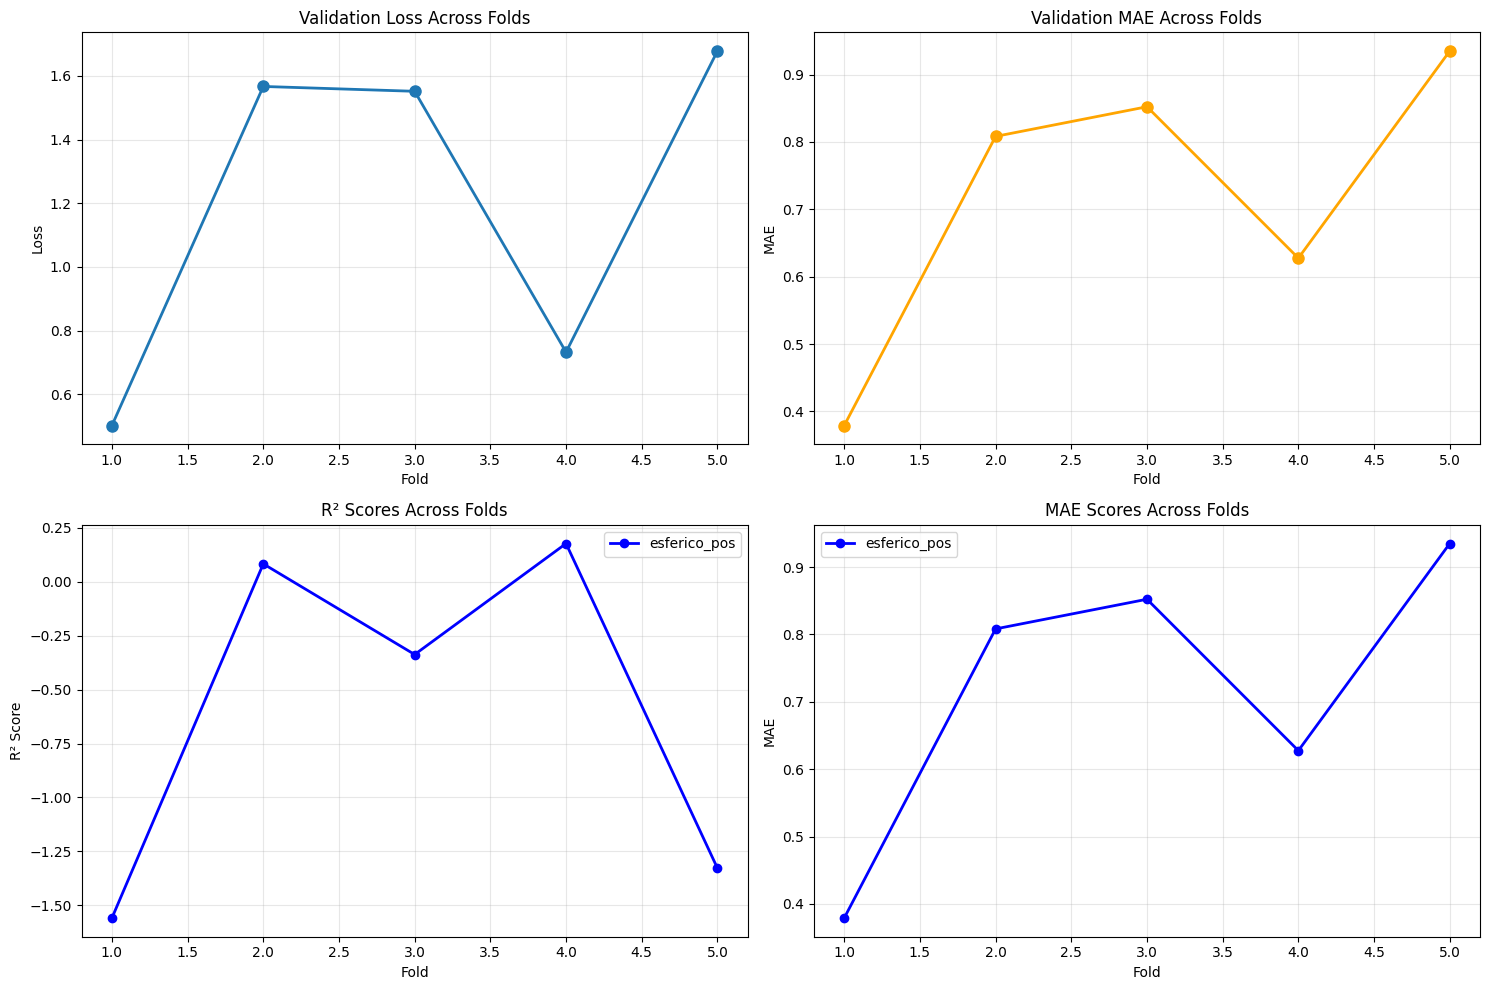

Training final model on entire dataset...
Epoch 1/100


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.6123 - mae: 1.2718 - val_loss: 0.4956 - val_mae: 0.5825
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4309 - mae: 1.1429 - val_loss: 0.4869 - val_mae: 0.5703
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9623 - mae: 1.1010 - val_loss: 0.5060 - val_mae: 0.5731
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7632 - mae: 0.9827 - val_loss: 0.5125 - val_mae: 0.5816
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6340 - mae: 0.9910 - val_loss: 0.5219 - val_mae: 0.5966
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8789 - mae: 1.0518 - val_loss: 0.5904 - val_mae: 0.6347
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6719 - mae: 0.9765 - val_loss: 0.6239 - val_mae: 0.6598
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5646 - mae: 0.8841 - val_loss: 0.6377 - val_mae: 0.6903
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1438 - mae: 0.

Final model - Loss: 1.2212, MAE: 0.7203
Model saved as ocular_ai_final.h5
Metadata saved as ocular_ai_final_metadata.pkl

MODEL PERFORMANCE SUMMARY
MSE  (Mean Squared Error):      1.1990
MAE  (Mean Absolute Error):     0.7203
R²   (Coefficient of Determination): -0.1990


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

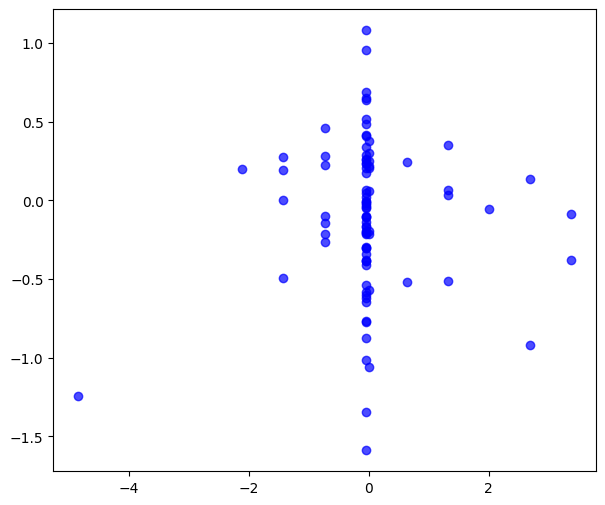

In [46]:
df = pd.read_excel("C:/pessoal/projetos_individuais/ia/Iso_olhos/dados/Pacientes_Torica_FINAL_check.xlsx")

model_ai = SimpleOcularAIModel()

# 🔹 1. Cross-validation para avaliar robustez do modelo
fold_results, all_predictions, all_actuals = model_ai.cross_validate(df, n_splits=5, epochs=100, batch_size=4)

# Análise dos resultados
results_df = model_ai.analyze_cross_validation_results(fold_results)
model_ai.plot_cv_results(results_df)

# 🔹 2. Treinar modelo final em todo dataset
final_model = model_ai.train_final_model(df, epochs=100, batch_size=4)

# 🔹 3. Salvar modelo e scaler
model_ai.save_model(filepath="ocular_ai_final")

# 🔹 4. Avaliar desempenho do modelo final (opcional)
X, y = model_ai.prepare_data(df)
X_scaled = model_ai.scaler.transform(X)
predictions = final_model.predict(X_scaled, verbose=0)
metrics = model_ai.evaluate_model_performance(y, predictions)

Simplified Model Architecture:


c:\pessoal\projetos_individuais\ia\Iso_olhos\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)


Training simplified model for 150 epochs...
Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 3.7405 - mae: 1.4407 - mape: 98390480.0000 - val_loss: 0.9828 - val_mae: 0.7926 - val_mape: 132388592.0000 - learning_rate: 0.0010
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4677 - mae: 1.4233 - mape: 63804780.0000 - val_loss: 0.9438 - val_mae: 0.7663 - val_mape: 129412448.0000 - learning_rate: 0.0010
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8652 - mae: 1.2325 - mape: 112706288.0000 - val_loss: 0.9103 - val_mae: 0.7597 - val_mape: 122764176.0000 - learning_rate: 0.0010
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0956 - mae: 1.1032 - mape: 70001664.0000 - val_loss: 0.8886 - val_mae: 0.7502 - val_mape: 114188192.0000 - learning_rate: 0.0010
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2666 - mae: 1.1363 - mape: 68713816.0000 - val_loss: 0.8647 - val_mae: 0.7341 - val_mape: 102529544.0000 - learning_rate: 0.0010
Epo

AttributeError: 'SimpleOcularAIModel' object has no attribute 'evaluate_model_performance'

In [ ]:
def evaluate_final_model(model, df, test_size=0.2):
    """
    Comprehensive evaluation of the final trained model
    """
    print("=" * 70)
    print("COMPREHENSIVE FINAL MODEL EVALUATION")
    print("=" * 70)
    
    # Prepare data
    X, y = model.prepare_data(df)
    
    # Split data (if you want to use a holdout test set)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Scale features
    X_test_scaled = model.scaler.transform(X_test)
    
    # Make predictions
    print("Making predictions on test set...")
    predictions = model.model.predict(X_test_scaled, verbose=0)
    
    # Calculate comprehensive metrics for each output
    target_names = ['esferico_pos']
    
    print("\n" + "=" * 70)
    print("PER-TARGET METRICS")
    print("=" * 70)
    
    metrics_summary = {}
    
    for i, name in enumerate(target_names):
        actual = y_test.iloc[:, i]
        predicted = predictions[:, i]
        
        # Calculate metrics
        mse = mean_squared_error(actual, predicted)
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mse)
        r2 = r2_score(actual, predicted)
        
        # Calculate additional metrics
        mape = np.mean(np.abs((actual - predicted) / actual)) * 100
        correlation = np.corrcoef(actual, predicted)[0, 1]
        
        metrics_summary[name] = {
            'MSE': mse,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'MAPE': mape,
            'Correlation': correlation
        }
        
        print(f"\n📊 {name.upper()} Metrics:")
        print(f"   Mean Squared Error (MSE): {mse:.4f}")
        print(f"   Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"   Mean Absolute Error (MAE): {mae:.4f}")
        print(f"   Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
        print(f"   R² Score: {r2:.4f}")
        print(f"   Correlation Coefficient: {correlation:.4f}")
        
        # Basic statistics
        print(f"   Actual Values - Mean: {actual.mean():.4f}, Std: {actual.std():.4f}")
        print(f"   Predicted Values - Mean: {predicted.mean():.4f}, Std: {predicted.std():.4f}")
    
    return predictions, y_test, metrics_summary, X_test_scaled

# Run the evaluation
final_predictions, final_y_test, final_metrics, X_test_scaled = evaluate_final_model(simple_model, df)

COMPREHENSIVE FINAL MODEL EVALUATION
Making predictions on test set...



PER-TARGET METRICS

📊 ESFERICO_POS Metrics:
   Mean Squared Error (MSE): 0.2165
   Root Mean Squared Error (RMSE): 0.4653
   Mean Absolute Error (MAE): 0.3405
   Mean Absolute Percentage Error (MAPE): 136803269831078368.00%
   R² Score: -0.1544
   Correlation Coefficient: 0.2498
   Actual Values - Mean: -0.1985, Std: 0.4456
   Predicted Values - Mean: -0.1057, Std: 0.2872

📊 CILINDRICO_POS Metrics:
   Mean Squared Error (MSE): 0.2521
   Root Mean Squared Error (RMSE): 0.5021
   Mean Absolute Error (MAE): 0.3469
   Mean Absolute Percentage Error (MAPE): inf%
   R² Score: 0.3741
   Correlation Coefficient: 0.6954
   Actual Values - Mean: 0.1032, Std: 0.6531
   Predicted Values - Mean: -0.0369, Std: 0.2850

📊 EIXO_POS Metrics:
   Mean Squared Error (MSE): 0.7852
   Root Mean Squared Error (RMSE): 0.8861
   Mean Absolute Error (MAE): 0.6635
   Mean Absolute Percentage Error (MAPE): 37161988074006672.00%
   R² Score: 0.2805
   Correlation Coefficient: 0.5869
   Actual Values - Mean: -0.259

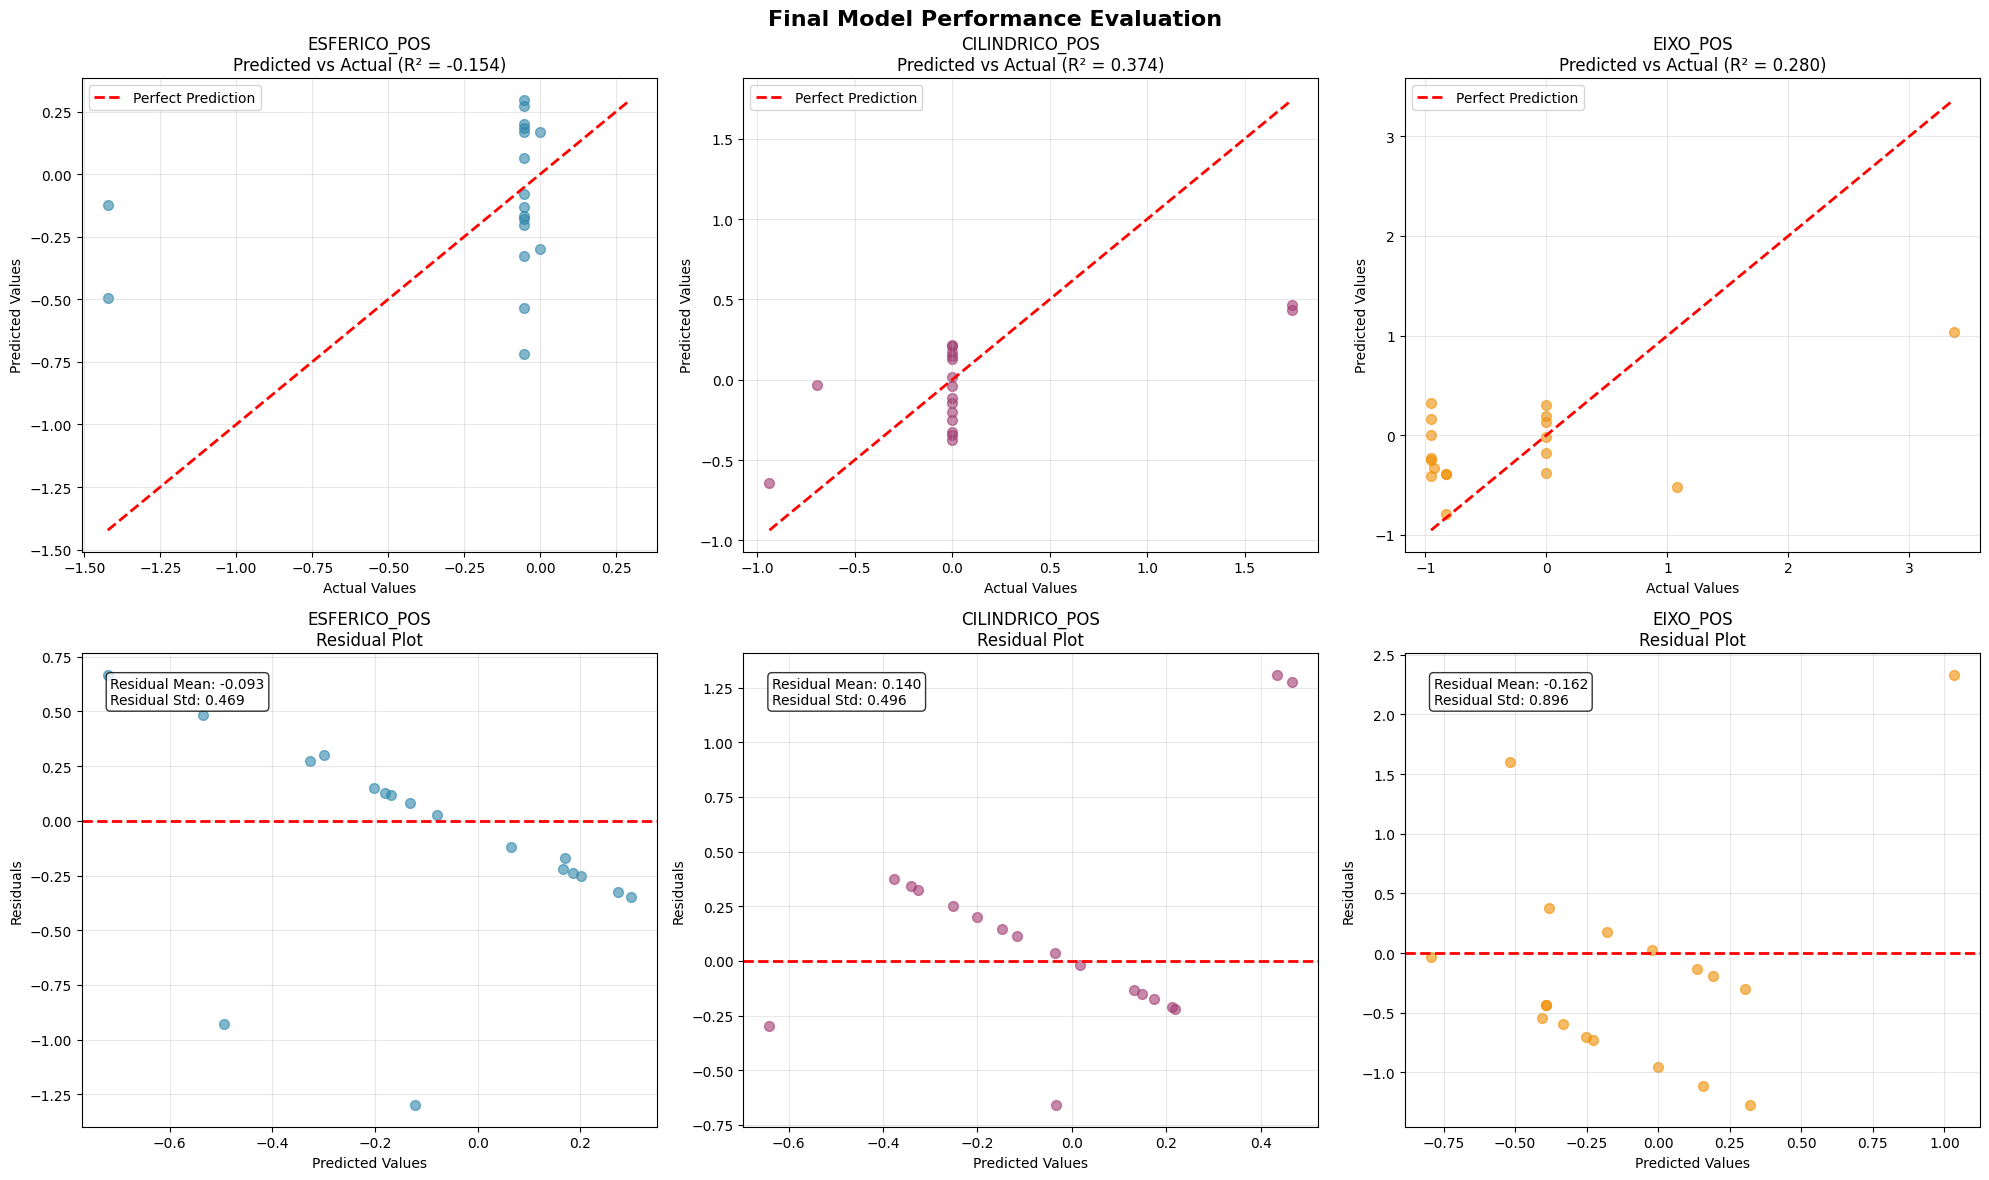

In [ ]:
def plot_final_evaluation(y_test, predictions, metrics_summary):
    """
    Create comprehensive visualization of model performance
    """
    target_names = ['esferico_pos']
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Final Model Performance Evaluation', fontsize=16, fontweight='bold')
    
    # 1. Predictions vs Actual (Scatter plots)
    for i, (name, color) in enumerate(zip(target_names, colors)):
        row, col = i // 3, i % 3
        if row == 0:
            ax = axes[row, col]
            
            actual = y_test.iloc[:, i]
            predicted = predictions[:, i]
            
            # Scatter plot
            ax.scatter(actual, predicted, alpha=0.6, color=color, s=50)
            
            # Perfect prediction line
            min_val = min(actual.min(), predicted.min())
            max_val = max(actual.max(), predicted.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
            
            ax.set_xlabel('Actual Values')
            ax.set_ylabel('Predicted Values')
            ax.set_title(f'{name.upper()}\nPredicted vs Actual (R² = {metrics_summary[name]["R2"]:.3f})')
            ax.grid(True, alpha=0.3)
            ax.legend()
    
    # 2. Residual plots
    for i, (name, color) in enumerate(zip(target_names, colors)):
        row, col = 1, i
        ax = axes[row, col]
        
        actual = y_test.iloc[:, i]
        predicted = predictions[:, i]
        residuals = actual - predicted
        
        # Residual plot
        ax.scatter(predicted, residuals, alpha=0.6, color=color, s=50)
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax.set_xlabel('Predicted Values')
        ax.set_ylabel('Residuals')
        ax.set_title(f'{name.upper()}\nResidual Plot')
        ax.grid(True, alpha=0.3)
        
        # Add residual statistics
        residual_mean = residuals.mean()
        residual_std = residuals.std()
        ax.text(0.05, 0.95, f'Residual Mean: {residual_mean:.3f}\nResidual Std: {residual_std:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Plot the evaluation results
plot_final_evaluation(final_y_test, final_predictions, final_metrics)